# Assignment 1 – Data Preparation
## UCI Bank Marketing Dataset

**Course:** Machine Learning Foundations
**Objective:** Data exploration and feature engineering prior to Logistic Regression.

*Edoardo Rigoletti*

# 1. Identifying the Prediction Target
## 1.1 Target Variable

Acording to the data set, the target variable for this assignment is `y`, which indicates whether the client subscribed to a term deposit (`yes` or `no`).

This variable represents the outcome of the marketing campaign and is the quantity we aim to predict.


## 1.2 Justification of the Prediction Objective

The objective of the project is to determine whether a contacted client subscribes to a term deposit.

Therefore, predicting `y` aligns directly with the business goal.

This is a binary classification problem, where:
   * Input features (X) describe the client and campaign information.
   * The output (y) represents the observed outcome after contact.

 ## 1.3 Variables That Should Not Be Treated as Targets

Some variables may appear highly predictive but should not be treated as targets, for example:

- `duration`: This represents the duration of the call. Since call duration is known only after the conversation takes place, using it would introduce temporal leakage.
- `pdays` or `previous`: These relate to past campaign interactions and may encode information related to previous outcomes, but they do not represent the objective of the current campaign.


# 2. Data Loading and Initial Exploration
## 2.1 Imports + Load the CSV

In [2]:
import pandas as pd
import numpy as np

# bank-additional.csv uses ";" as separator
df = pd.read_csv("bank-additional.csv", sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## 2.2 Basic structure

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (4119, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-n

Intital dataset info
* Shape: (4119, 21)
* RangeIndex: 4119 entries
* Data columns (total 21 columns):
* dtypes: float64(5), int64(5), str(11)

## 2.3 Na chek

In [4]:
df.isna().sum().sort_values(ascending=False).head(15)

age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
dtype: int64

#### No explicit missing values (NaN) are present in the dataset. However, several categorical variables contain the value "unknown", which represents implicit missingness. These cases will be handled explicitly in Section 5.

## 2.4 Is the data set balanced?

In [5]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

### The target variable is highly imbalanced. Approximately 89% of clients did not subscribe, while only about 11% subscribed.

#### This imbalance suggests that accuracy alone may not be an appropriate evaluation metric, as a trivial model predicting the majority class would already achieve high accuracy.

## 2.5Implicit Missing Values

In [6]:
cat_cols = df.select_dtypes(include="object").columns

unknown_counts = {
    col: (df[col] == "unknown").sum()
    for col in cat_cols
}

pd.Series(unknown_counts).sort_values(ascending=False)


/var/folders/4k/y3nlq38563n_8fvbz0xwzm9r0000gn/T/ipykernel_53724/2751482649.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


default        803
education      167
housing        105
loan           105
job             39
marital         11
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64

#### We know that implicit missingness is precent, because several categorical variables contain the value "unknown".The variable default has the highest proportion of unknown values, followed by education, housing, and loan.

#### Since missingness may be informative (e.g., refusal to disclose financial status), it will be treated carefully in Section 5 rather than being removed immediately.

* In porcentages

In [7]:
(pd.Series(unknown_counts) / len(df) * 100).sort_values(ascending=False)

default        19.495023
education       4.054382
housing         2.549162
loan            2.549162
job             0.946832
marital         0.267055
contact         0.000000
month           0.000000
day_of_week     0.000000
poutcome        0.000000
y               0.000000
dtype: float64

# 2.6 Required Visualizations
## Numerical Variables
### Age

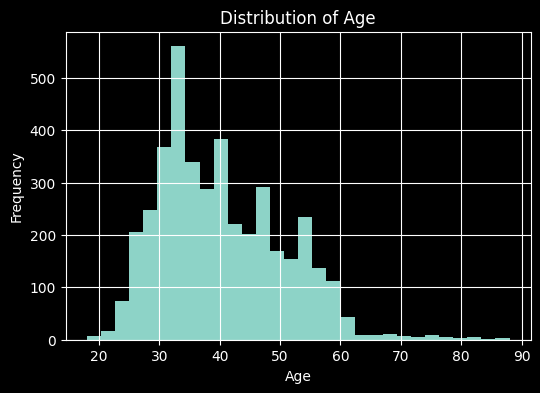

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["age"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Campaign (number of contacts)

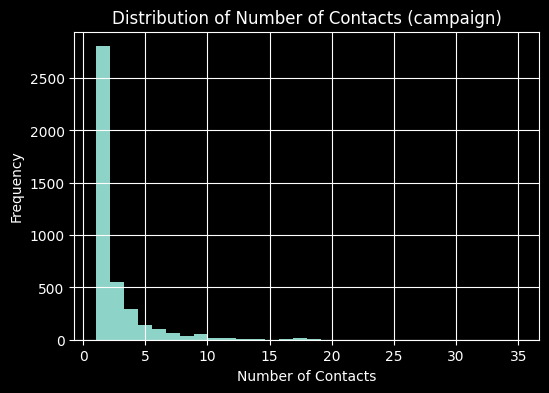

In [9]:
plt.figure(figsize=(6,4))
df["campaign"].hist(bins=30)
plt.title("Distribution of Number of Contacts (campaign)")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.show()

### Numerical Variables in Interpretation.
#### Age distribution is somewhat right-skewed, especially where most clients are between 30 and 50 years old. But there are extreme values of their own, relatively rare. However, due to the varying magnitude of the variables, feature scaling may need to be done. The variable campaign is highly right-skewed and the majority of clients are contacted only a few times (1–3, for the majority) and that value is heavily skewed right-to-higher. In this way, this skewness suggests scaling will be crucial when deploying Logistic Regression.

## Categorical Variables
### Job


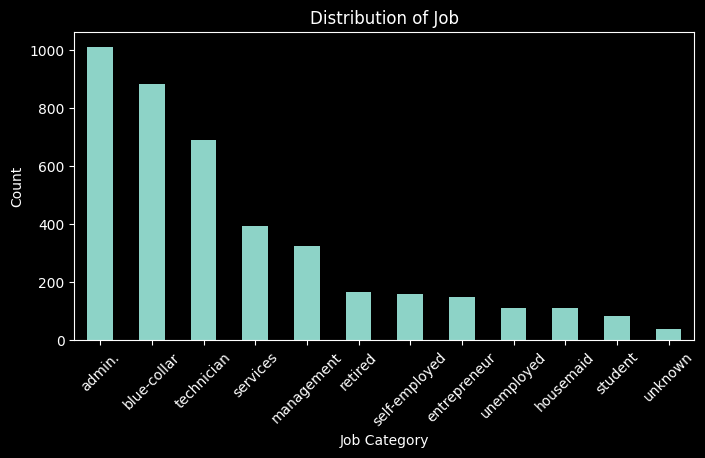

In [10]:
plt.figure(figsize=(8,4))
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job")
plt.xlabel("Job Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Education

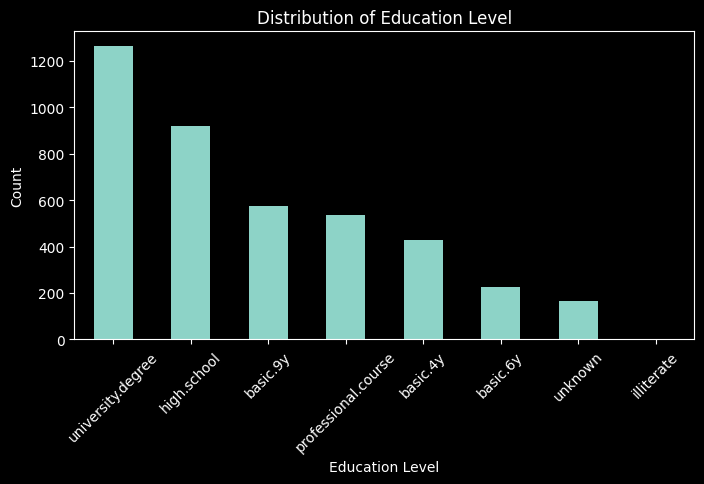

In [11]:
plt.figure(figsize=(8,4))
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



### Interpretation of Categorical Variables.
#### The job variable indicates that some factors (e.g., admin., blue-collar) dominate our dataset. This will enrich the dimension following one-hot encoding. The education variable seems to be ordinal because there are ordered levels (basic education to university degree). That you should consider when deciding on an encoding strategy.

# 3. Prediction-Time Constraints and Leakage Risks


### Leakage Risk

#### the variable `duration` represents the length of the phone call. This value is only known after the conversation and is not available at prediction time. Having duration as a feature would also lead to temporal leakage in that longer calls are heavily correlated to the final decision the client makes. For instance, very short calls probably reflect non-subscription, whereas longer ones may represent higher engagement. Adopting this variable would enable the model to indirectly learn information about the outcome, resulting in unrealistically high performance when training but poor generalization when practicing that performance in practice. Thus, duration will be excluded from the feature set.

# 4. Data Splitting Strategy


#### The dataset must be split before applying any transformation that learns parameters from data (such as imputation, scaling, encoding, or feature selection). If these transformations are computed on the entire dataset, information from the validation and test sets would leak into the training process, leading to overly optimistic performance estimates.

* 60/20/20 strategy

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"]

# 80/20 split -> train_full and test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 75/25 split of train_full -> train and val
# (0.25 of 0.80 = 0.20 of total) -> 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)

In [13]:

y_train.value_counts(normalize=True)
y_val.value_counts(normalize=True)
y_test.value_counts(normalize=True)

y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

#### The dataset was split into training (60%), validation (20%), and test (20%) sets using stratified sampling with respect to the target variable.Stratification ensures that the class distribution (approximately 89% “no” and 11% “yes”) is preserved across all splits.

### Apply prediction-time constraints (leakage removal)

#### Based on Section 3, the variable `duration` is not available at prediction time and would introduce temporal leakage. Therefore, it is removed from all feature sets after splitting to keep train/validation/test consistent.

In [14]:

cols_to_drop = ["duration"]

X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

assert "duration" not in X_train.columns

# 5. Managing Missing Values


#### The dataset does not contain explicit missing values (NaN). However, several categorical variables include the value “unknown”, representing implicit missingness.Since missingness may carry predictive information (e.g., refusal to disclose financial status), “unknown” will be treated as a valid separate category rather than being removed or imputed. This approach preserves all observations and avoids introducing additional assumptions.

# 6. Encoding Categorical Variables

### 6.1 Identify categorical vs numerical columns

In [15]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

cat_cols, num_cols

/var/folders/4k/y3nlq38563n_8fvbz0xwzm9r0000gn/T/ipykernel_53724/529091984.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns.tolist()


(['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'],
 ['age',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'])

#### This clearly separates Categorical variables to encode and Numerical variables to scale later

### 6.2 Encoding strategy

#### All categorical variables are treated as nominal and encoded using One-Hot Encoding. Although the variable education has an apparent order, we avoid imposing ordinal encoding to prevent assuming equal distances between education levels. One-Hot Encoding avoids introducing artificial structure into the model and allows Logistic Regression to learn separate coefficients for each category.

### 6.3 Fit encoder on training set only

In [16]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[cat_cols])

X_train_encoded = encoder.transform(X_train[cat_cols])
X_val_encoded   = encoder.transform(X_val[cat_cols])
X_test_encoded  = encoder.transform(X_test[cat_cols])

### 6.4 Combine back with numerical columns

In [17]:
import numpy as np

X_train_final = np.hstack([X_train[num_cols].values, X_train_encoded])
X_val_final   = np.hstack([X_val[num_cols].values, X_val_encoded])
X_test_final  = np.hstack([X_test[num_cols].values, X_test_encoded])

#### The encoder was fitted using only the training set to avoid preprocessing leakage. Validation and test sets were transformed using the learned mapping.

* One-hot encoding increases the dimensionality of the dataset by creating one feature per category, allowing the model to learn separate coefficients without imposing artificial ordering.

# 7. Feature Scaling


* The scaler was fitted exclusively on the training data and subsequently applied to the validation and test sets to prevent preprocessing leakage.

### Implementation

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training numerical features
scaler.fit(X_train[num_cols])

X_train_scaled = scaler.transform(X_train[num_cols])
X_val_scaled   = scaler.transform(X_val[num_cols])
X_test_scaled  = scaler.transform(X_test[num_cols])

### Combine

In [19]:
import numpy as np

X_train_final = np.hstack([X_train_scaled, X_train_encoded])
X_val_final   = np.hstack([X_val_scaled, X_val_encoded])
X_test_final  = np.hstack([X_test_scaled, X_test_encoded])

#### Numerical variables were standardized using Z-score scaling. The scaler was fitted exclusively on the training set to prevent information leakage. Scaling improves numerical stability and ensures that regularization penalties affect coefficients.

# 8. Feature Selection


### 8.1 Low Variance Features

In [20]:
X_train[num_cols].var().sort_values()

previous              0.294021
cons.price.idx        0.336838
emp.var.rate          2.457971
euribor3m             3.010375
campaign              6.407185
cons.conf.idx        21.294224
age                 105.770881
nr.employed        5503.451140
pdays             40516.217206
dtype: float64

#### None of the numerical features exhibit near-zero variance. Therefore, no features are removed based on low variance.

### 8.2 — Correlation

* A correlation threshold of 0.9 was used to identify strong linear relationships indicative of multicollinearity.

In [21]:
import numpy as np

corr_matrix = X_train[num_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    (row, col, upper.loc[row, col])
    for row in upper.index
    for col in upper.columns
    if upper.loc[row, col] > 0.9
]

high_corr

[('emp.var.rate', 'euribor3m', np.float64(0.9691107426560807)),
 ('euribor3m', 'nr.employed', np.float64(0.9431859176111577))]

#### Strong correlations were observed between emp.var.rate, euribor3m, and nr.employed (correlation > 0.9). To reduce multicollinearity and improve coefficient stability in Logistic Regression, `emp.var.rate` and `nr.employed` were removed, retaining euribor3m as a representative macroeconomic indicator.

In [22]:
cols_to_drop_corr = ["emp.var.rate", "nr.employed"]

X_train = X_train.drop(columns=cols_to_drop_corr)
X_val   = X_val.drop(columns=cols_to_drop_corr)
X_test  = X_test.drop(columns=cols_to_drop_corr)

num_cols = [col for col in num_cols if col not in cols_to_drop_corr]

# 9. Addressing Class Imbalance


### 9.1

### The target variable is imbalanced (~89% “no”, ~11% “yes”). In such settings, accuracy can be misleading because a majority-class predictor would achieve high accuracy while failing to detect subscribers.

### Instead of resampling, we use class-weighted Logistic Regression (class_weight="balanced"), which increases the penalty for misclassifying the minority class. This approach addresses imbalance without altering the validation/test distributions, which must remain representative for unbiased evaluation.

* Class weighting was applied exclusively during model training. The validation and test sets were left unchanged to preserve the original data distribution and ensure unbiased evaluation.

### 9.2 train Logistic Regression with class weights

Validation metrics (LogReg, class_weight='balanced'):
Accuracy:  0.8398
Precision: 0.3600
Recall:    0.6000


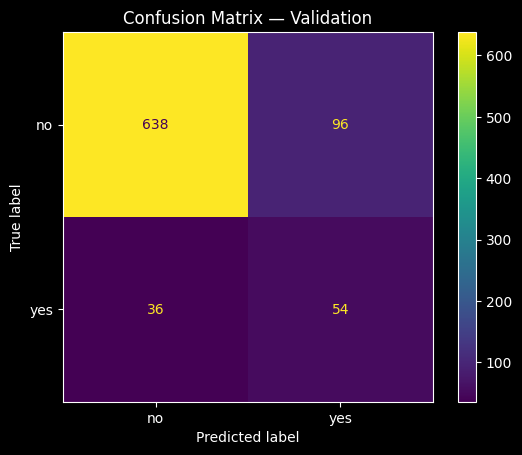

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression with class weights
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr.fit(X_train_final, y_train)

y_val_pred = lr.predict(X_val_final)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes", zero_division=0)
rec = recall_score(y_val, y_val_pred, pos_label="yes", zero_division=0)

print("Validation metrics (LogReg, class_weight='balanced'):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — Validation")
plt.show()

### Zero Rule baseline

In [24]:
majority_class = y_train.value_counts().idxmax()
y_val_pred_zero = np.full_like(y_val, fill_value=majority_class)

acc_zero = accuracy_score(y_val, y_val_pred_zero)
prec_zero = precision_score(y_val, y_val_pred_zero, pos_label="yes", zero_division=0)
rec_zero = recall_score(y_val, y_val_pred_zero, pos_label="yes", zero_division=0)

print("Validation metrics (Zero Rule baseline):")
print(f"Accuracy:  {acc_zero:.4f}")
print(f"Precision: {prec_zero:.4f}")
print(f"Recall:    {rec_zero:.4f}")
print(f"Majority class predicted: {majority_class}")

Validation metrics (Zero Rule baseline):
Accuracy:  0.8908
Precision: 0.0000
Recall:    0.0000
Majority class predicted: no


# 10 Conclution

### The data preparation tasks were executed in a structured order to prevent information leakage and ensure methodological consistency.

### The prediction target was identified prior to any transformation. The raw dataset was explored to understand its structure and class imbalance. The dataset was then split into training, validation, and test sets before applying any transformation that learns parameters from data (such as imputation, encoding, scaling, feature selection, or imbalance handling), thereby preventing preprocessing leakage.

### Leakage-prone variables (e.g., duration) were removed based on prediction-time constraints. Missing values were handled without incorporating information from validation or test sets. Categorical encoding and numerical scaling were fitted exclusively on the training data and subsequently applied to validation and test sets. Class imbalance was addressed using class weighting during model training to maintain unbiased evaluation.

### This structured ordering ensures that model evaluation reflects realistic deployment conditions and prevents artificially inflated performance estimates.

### The observed performance aligns with theoretical expectations for imbalanced classification problems, confirming the correctness of the preprocessing pipeline.